In [1]:
import numpy as np
import matplotlib.pyplot as plt

print("numpy version:", np.__version__)
print("Everything is working!")

numpy version: 2.0.2
Everything is working!


In [2]:
from tensorflow.keras.datasets import fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("Training images:", x_train.shape)
print("Test images:", x_test.shape)
print("Each image is:", x_train[0].shape, "pixels")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Test images: (10000, 28, 28)
Each image is: (28, 28) pixels


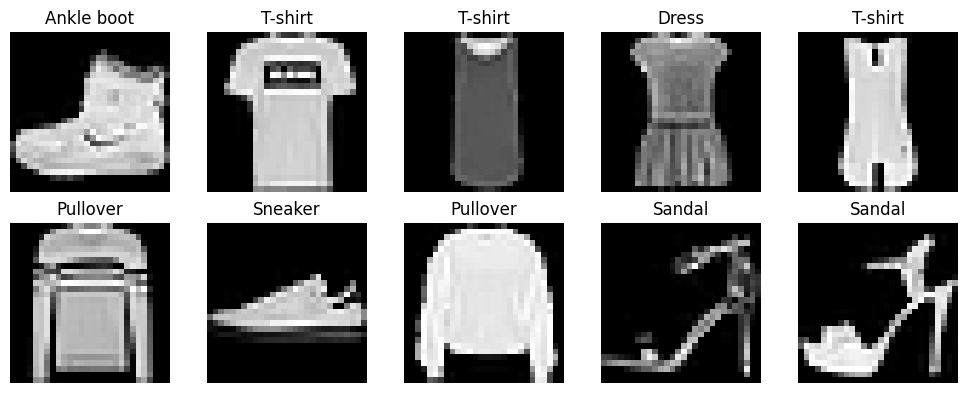

In [3]:
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [4]:
# Scale pixel values from 0-255 to 0-1 (makes training easier)
x_train = x_train / 255.0
x_test  = x_test  / 255.0

# Add a channel dimension — shape goes from (60000,28,28) to (60000,28,28,1)
x_train = x_train[..., np.newaxis]
x_test  = x_test[...,  np.newaxis]

print("Final training shape:", x_train.shape)
print("Final test shape:", x_test.shape)

Final training shape: (60000, 28, 28, 1)
Final test shape: (10000, 28, 28, 1)


In [5]:
# ─── CONVOLUTION LAYER ───────────────────────────────────────────

def conv_forward(image, filters, bias, stride=1, pad=1):
    """
    image   : shape (H, W, C)         — one input image
    filters : shape (fH, fW, C, nF)   — nF filters, each fH x fW x C
    bias    : shape (nF,)
    returns : output feature map
    """
    H, W, C      = image.shape
    fH, fW, _, nF = filters.shape

    # Add padding (zeros around the border so edges are not lost)
    img_pad = np.pad(image, ((pad,pad),(pad,pad),(0,0)), mode='constant')

    out_H = (H + 2*pad - fH) // stride + 1
    out_W = (W + 2*pad - fW) // stride + 1
    output = np.zeros((out_H, out_W, nF))

    for f in range(nF):                        # for each filter
        for i in range(out_H):
            for j in range(out_W):
                h_start = i * stride
                w_start = j * stride
                region  = img_pad[h_start:h_start+fH, w_start:w_start+fW, :]
                output[i, j, f] = np.sum(region * filters[:,:,:,f]) + bias[f]

    return output


def relu(x):
    """ReLU just turns every negative number into 0."""
    return np.maximum(0, x)


def conv_backward(d_out, image, filters, stride=1, pad=1):
    """
    Computes gradients for filters, bias, and input image.
    d_out : gradient flowing back from the next layer
    """
    H, W, C        = image.shape
    fH, fW, _, nF  = filters.shape
    out_H, out_W, _ = d_out.shape

    img_pad   = np.pad(image, ((pad,pad),(pad,pad),(0,0)), mode='constant')
    d_img_pad = np.zeros_like(img_pad)
    d_filters = np.zeros_like(filters)
    d_bias    = np.zeros(nF)

    for f in range(nF):
        d_bias[f] = np.sum(d_out[:,:,f])
        for i in range(out_H):
            for j in range(out_W):
                h_start = i * stride
                w_start = j * stride
                region  = img_pad[h_start:h_start+fH, w_start:w_start+fW, :]
                d_filters[:,:,:,f] += region * d_out[i, j, f]
                d_img_pad[h_start:h_start+fH, w_start:w_start+fW, :] += \
                    filters[:,:,:,f] * d_out[i, j, f]

    # Remove padding to get the original image gradient
    d_img = d_img_pad[pad:-pad, pad:-pad, :]
    return d_img, d_filters, d_bias


print("Convolution layer defined!")

Convolution layer defined!


In [6]:
# ─── MAXPOOL LAYER ───────────────────────────────────────────────

def maxpool_forward(image, size=2, stride=2):
    """
    Takes the MAXIMUM value in each 2x2 region.
    Shrinks the image by half.
    Also saves WHERE the max was — needed for backprop.
    """
    H, W, C = image.shape
    out_H = (H - size) // stride + 1
    out_W = (W - size) // stride + 1
    output = np.zeros((out_H, out_W, C))
    mask   = np.zeros_like(image)   # remembers which pixel was the max

    for c in range(C):
        for i in range(out_H):
            for j in range(out_W):
                h_start = i * stride
                w_start = j * stride
                region  = image[h_start:h_start+size, w_start:w_start+size, c]
                max_val = np.max(region)
                output[i, j, c] = max_val
                # mark which position had the max (for backprop)
                mask[h_start:h_start+size, w_start:w_start+size, c] += \
                    (region == max_val)

    return output, mask


def maxpool_backward(d_out, mask, size=2, stride=2):
    """
    Gradient only flows back through the position that was the max.
    Everything else gets 0.
    """
    d_input = np.zeros_like(mask)
    _, _, C  = d_out.shape
    out_H, out_W, _ = d_out.shape

    for c in range(C):
        for i in range(out_H):
            for j in range(out_W):
                h_start = i * stride
                w_start = j * stride
                d_input[h_start:h_start+size, w_start:w_start+size, c] += \
                    mask[h_start:h_start+size, w_start:w_start+size, c] * d_out[i, j, c]

    return d_input


print("MaxPool layer defined!")

MaxPool layer defined!


In [7]:
# ─── FLATTEN LAYER ───────────────────────────────────────────────

def flatten_forward(image):
    """Converts 3D (H, W, C) into 1D vector. Saves shape for backprop."""
    original_shape = image.shape
    return image.flatten(), original_shape

def flatten_backward(d_out, original_shape):
    """Reshapes the gradient back to 3D."""
    return d_out.reshape(original_shape)

print("Flatten layer defined!")

Flatten layer defined!


In [8]:
# ─── FULLY CONNECTED LAYER ───────────────────────────────────────

def softmax(x):
    """
    Converts raw scores into probabilities (all add up to 1).
    Example: [2.1, 0.5, 1.3] → [0.6, 0.1, 0.3]
    """
    e_x = np.exp(x - np.max(x))   # subtract max for numerical stability
    return e_x / e_x.sum()


def fc_forward(x, weights, bias):
    """
    x       : 1D input vector  (flattened image)
    weights : 2D matrix        (input_size × num_classes)
    bias    : 1D vector        (num_classes,)
    returns : probabilities for each of the 10 classes
    """
    scores = np.dot(x, weights) + bias
    probs  = softmax(scores)
    return probs


def cross_entropy_loss(probs, true_label):
    """
    Measures how wrong the prediction is.
    Lower = better. 0 = perfect.
    """
    return -np.log(probs[true_label] + 1e-9)


def fc_backward(probs, true_label, x, weights):
    """
    Computes gradients so weights can be updated.
    """
    d_scores          = probs.copy()
    d_scores[true_label] -= 1        # the key trick in softmax backprop

    d_weights = np.outer(x, d_scores)
    d_bias    = d_scores
    d_x       = np.dot(weights, d_scores)

    return d_x, d_weights, d_bias


print("Fully Connected layer defined!")

Fully Connected layer defined!


In [9]:
# ─── INITIALIZE WEIGHTS ──────────────────────────────────────────

np.random.seed(42)   # so results are reproducible

# Convolution filter: 3x3, 1 input channel, 8 filters
filters = np.random.randn(3, 3, 1, 8) * 0.1
bias_conv = np.zeros(8)

# After conv+pool on a 28x28 image:
# conv output  → 28x28x8  (with pad=1)
# maxpool output → 14x14x8
# flattened    → 14*14*8 = 1568
fc_input_size = 14 * 14 * 8
num_classes   = 10

# Fully connected weights
weights_fc = np.random.randn(fc_input_size, num_classes) * 0.01
bias_fc    = np.zeros(num_classes)

print("Filter shape   :", filters.shape)
print("FC weight shape:", weights_fc.shape)
print("Weights initialized!")

Filter shape   : (3, 3, 1, 8)
FC weight shape: (1568, 10)
Weights initialized!


In [10]:
# ─── FORWARD PASS ────────────────────────────────────────────────

def forward_pass(image, filters, bias_conv, weights_fc, bias_fc):
    """
    Runs one image through the entire CNN.
    Returns the prediction probabilities + everything needed for backprop.
    """
    # 1. Convolution + ReLU
    conv_out  = relu(conv_forward(image, filters, bias_conv))

    # 2. MaxPool
    pool_out, pool_mask = maxpool_forward(conv_out)

    # 3. Flatten
    flat_out, flat_shape = flatten_forward(pool_out)

    # 4. Fully Connected → probabilities
    probs = fc_forward(flat_out, weights_fc, bias_fc)

    return probs, conv_out, pool_out, pool_mask, flat_out, flat_shape


# Quick test on ONE image
test_image = x_train[0]          # shape (28, 28, 1)
probs, *_  = forward_pass(test_image, filters, bias_conv, weights_fc, bias_fc)

print("Output probabilities:", np.round(probs, 3))
print("Predicted class     :", np.argmax(probs))
print("Actual class        :", y_train[0], "→", class_names[y_train[0]])
print("Forward pass works!")

Output probabilities: [0.097 0.101 0.096 0.101 0.101 0.096 0.1   0.104 0.1   0.103]
Predicted class     : 7
Actual class        : 9 → Ankle boot
Forward pass works!


In [11]:
# ─── TRAINING LOOP ───────────────────────────────────────────────

learning_rate = 0.005
num_epochs    = 2        # keep low for now — each epoch takes a few minutes
train_size    = 1000     # use 1000 images to keep it fast on Colab

print("Starting training...\n")

for epoch in range(num_epochs):
    total_loss    = 0
    correct       = 0

    for i in range(train_size):
        image      = x_train[i]          # shape (28,28,1)
        true_label = y_train[i]

        # ── Forward pass ──────────────────────────────
        probs, conv_out, pool_out, pool_mask, flat_out, flat_shape = \
            forward_pass(image, filters, bias_conv, weights_fc, bias_fc)

        # ── Loss ──────────────────────────────────────
        loss       = cross_entropy_loss(probs, true_label)
        total_loss += loss

        if np.argmax(probs) == true_label:
            correct += 1

        # ── Backward pass (backpropagation) ───────────
        d_flat, d_weights_fc, d_bias_fc = fc_backward(
            probs, true_label, flat_out, weights_fc)

        d_pool  = flatten_backward(d_flat, flat_shape)
        d_conv  = maxpool_backward(d_pool, pool_mask)

        # ReLU backward (gradient is 0 where conv output was 0)
        d_conv[conv_out <= 0] = 0

        d_img, d_filters, d_bias_conv = conv_backward(
            d_conv, image, filters)

        # ── Update weights ────────────────────────────
        weights_fc -= learning_rate * d_weights_fc
        bias_fc    -= learning_rate * d_bias_fc
        filters    -= learning_rate * d_filters
        bias_conv  -= learning_rate * d_bias_conv

        # Print progress every 100 images
        if (i + 1) % 100 == 0:
            print(f"  Epoch {epoch+1} | Image {i+1}/{train_size} "
                  f"| Loss: {total_loss/(i+1):.3f} "
                  f"| Accuracy: {correct/(i+1)*100:.1f}%")

    print(f"\nEpoch {epoch+1} done — "
          f"Loss: {total_loss/train_size:.3f} | "
          f"Accuracy: {correct/train_size*100:.1f}%\n")

print("Training complete!")

Starting training...

  Epoch 1 | Image 100/1000 | Loss: 2.263 | Accuracy: 21.0%
  Epoch 1 | Image 200/1000 | Loss: 2.179 | Accuracy: 26.0%
  Epoch 1 | Image 300/1000 | Loss: 2.073 | Accuracy: 28.7%
  Epoch 1 | Image 400/1000 | Loss: 1.945 | Accuracy: 33.5%
  Epoch 1 | Image 500/1000 | Loss: 1.789 | Accuracy: 38.8%
  Epoch 1 | Image 600/1000 | Loss: 1.706 | Accuracy: 41.3%
  Epoch 1 | Image 700/1000 | Loss: 1.604 | Accuracy: 45.1%
  Epoch 1 | Image 800/1000 | Loss: 1.527 | Accuracy: 46.9%
  Epoch 1 | Image 900/1000 | Loss: 1.471 | Accuracy: 48.3%
  Epoch 1 | Image 1000/1000 | Loss: 1.436 | Accuracy: 49.4%

Epoch 1 done — Loss: 1.436 | Accuracy: 49.4%

  Epoch 2 | Image 100/1000 | Loss: 0.874 | Accuracy: 74.0%
  Epoch 2 | Image 200/1000 | Loss: 0.847 | Accuracy: 73.0%
  Epoch 2 | Image 300/1000 | Loss: 0.928 | Accuracy: 70.3%
  Epoch 2 | Image 400/1000 | Loss: 0.947 | Accuracy: 70.2%
  Epoch 2 | Image 500/1000 | Loss: 0.893 | Accuracy: 72.0%
  Epoch 2 | Image 600/1000 | Loss: 0.907 | Ac

Test Accuracy: 76.2%
Correct: 381 / 500
